In [ ]:
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

## Importing libraries

In [3]:
import numpy as np
from PIL import Image

## Load Image

In [4]:
img=Image.open('clothing-dataset-small/train/pants/0098b991-e36e-4ef1-b5ee-4154b21e2a92.jpg')

#Resize to target img
img = img.resize((224,224))

x = np.array(img)
print(x.shape)

(224, 224, 3)


# Pretrained Models

Instead of training from scratch, we use pre-trained models on ImageNet.

In [5]:
import torch
import torchvision.models as models
from torchvision import transforms

ImageNet is a dataset with a lot of images, contains all sorts of animals, objects, etc.. It's a dataset for general-purpose image classification. Big companies like Google or meta or universities with acces to a lot of data and computers, took this dataset, some neural networks, trained on them on ImageNet and shared the results. There are different kind of models: Xception, VGG, ResNet,.... They have different architectures which is how exactly the layers of a neural network are arranged inside a model.

In [6]:
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
  

## Preprocessing

This model expects the input to look in a certain way. When Mobilenet was trained, all images were preprocessed with a special function, so we have to apply exactly the same function to our data:

In [7]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

After preprocessing, our image no longer contains numbers between 0 and 255, they are converted to numbers between -1 and 1.

In [8]:
img = Image.open('clothing-dataset-small/train/pants/0098b991-e36e-4ef1-b5ee-4154b21e2a92.jpg')
img_t = preprocess(img)
batch_t = torch.unsqueeze(img_t, 0)

with torch.no_grad():
    output = model(batch_t)

_, indices = torch.sort(output, descending=True)

In [9]:
indices.shape

torch.Size([1, 1000])

The shape is (1,1000), 1000 classes, one image. Each value in the array is the probability that our image belongs to that class

## Decoding the predictions

To make sense of the output we need to know which class each of the 1000 values corresponds to. There is another function, it looks at the predictions and makes them human-readable.

In [10]:
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt -O imagenet_classes.txt

--2026-09-17 09:35:11--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 416 Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [11]:
with open('imagenet_classes.txt', 'r') as f:
    categories = [s.strip() for s in f.readlines()]

top5_indices = indices[0,:5].tolist()
top5_classes = [categories[i] for i in top5_indices]

print("Top 5 predictions:")
for i, class_name in enumerate(top5_classes):
    print(f"{i+1}: {class_name}")

Top 5 predictions:
1: jean
2: suit
3: cardigan
4: sweatshirt
5: overskirt


# Convolutional Neural Networks

Type of NN used mostly for images. They consists of different types of layers, and one of them is called a convolutional layer. We feed the image to a CNN and it outputs a prediction.

Two main types of layers in a convolutional neural network:
- Convolutional layers
- Dense layers

## Convolutional layers and filters

Consist of filters, a filter is kind of a small image, 5x5 or smaller, and there are quite a few of them in a layer. The filter contain simple shapes: simple lines, stripes, circles. We take our image, take a filter, and slide this filter across the image. Every time we apply the filter, we check how similar the filter is to the part of the image it currently covers. The similarity is a number: zeros means no similarity, a higher number means bigger similarity. Record this for each position of the filter, the resulting array is called a feature map

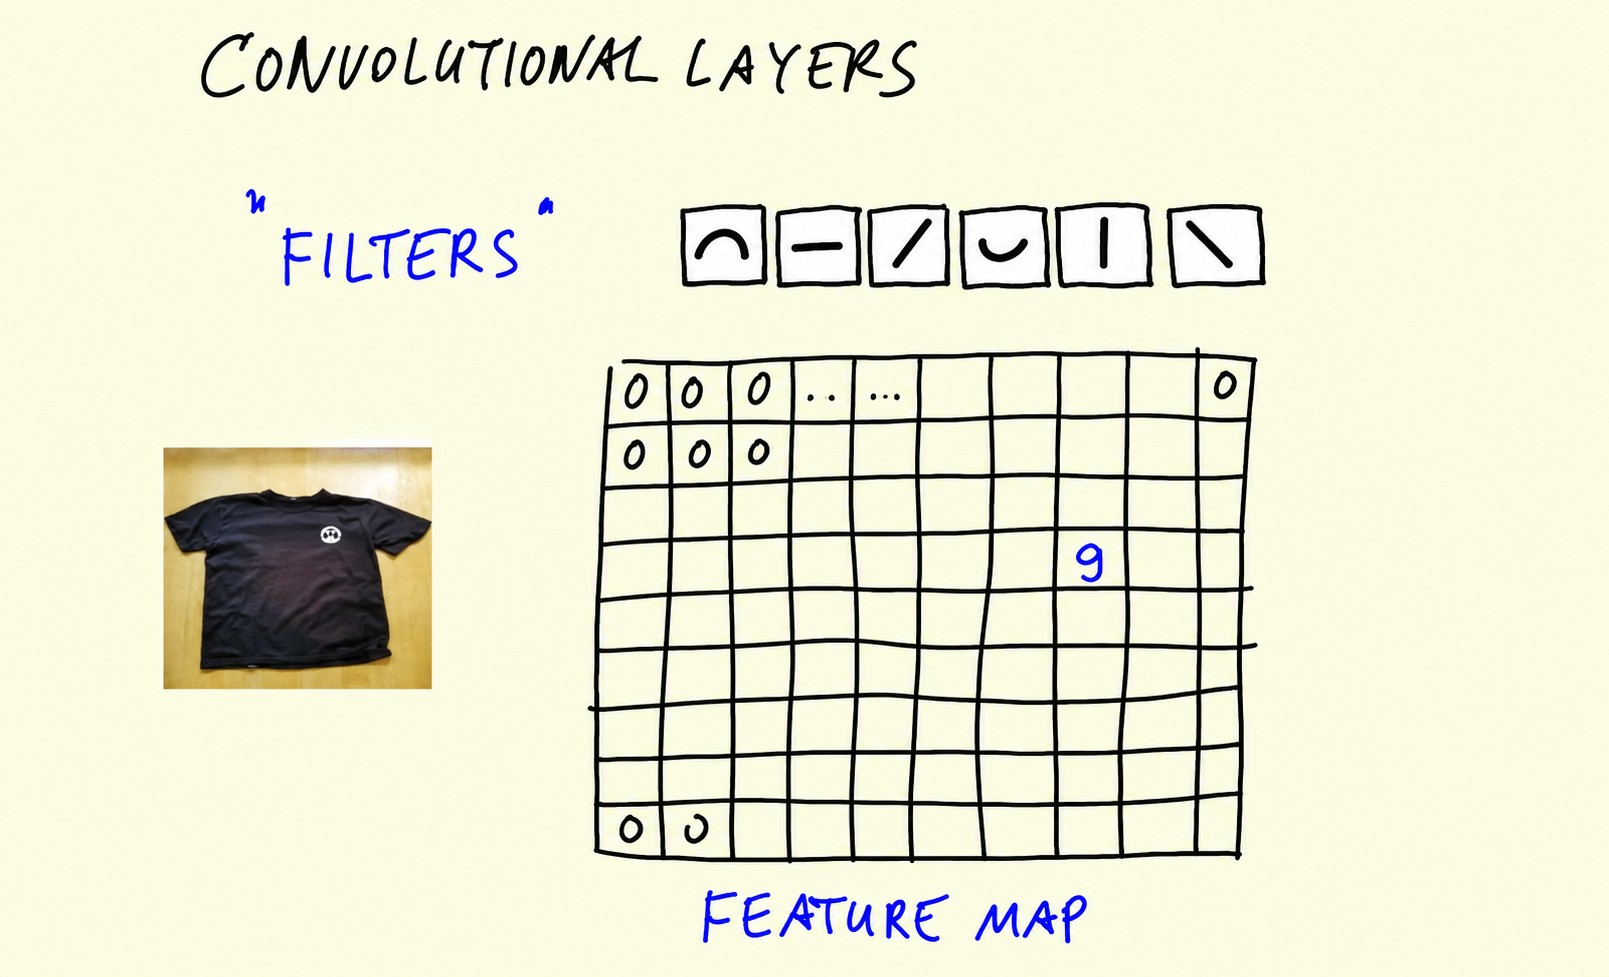

Feature map is the result of applying one filter to an image: we slide the filter across the image, compute the similarity at every position, and record it. High values mean the filter is similar to that part of the image. We do this for each filter. If a convolutional layer has six filters, it produces six feature maps, one per filter

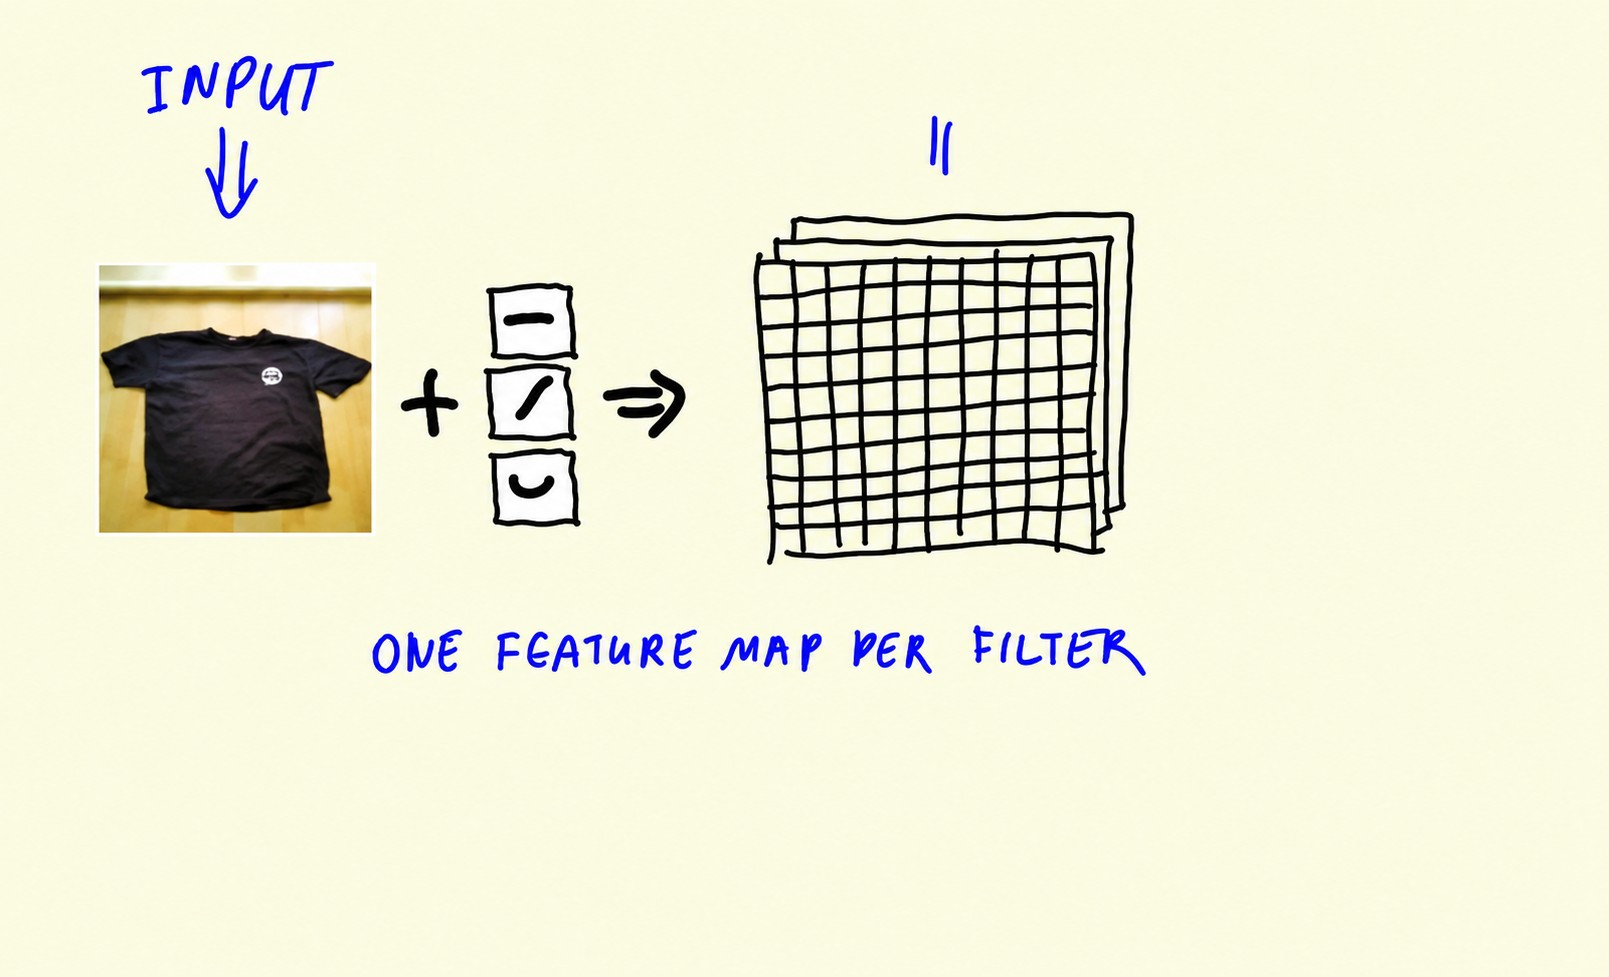

## Chaining convolutional layers

The output of the first convolutional layer is a set of feature maps, we can treat this output as a new image, an image that we made from the original one, and feed it to another convolutional layer. This layer has its own set of filters, applies them to the output of the first layer, and produces its own feature maps:

If the first layer has 6 filter and produces 6 feature maps, the second has 12 filters and produces 12 feature maps, and we keep going with a third layer. Because of this chaining, each layer learns more and more complex filters. These filters are what a neural network learns during training. The first convolutional layer typically learns simple filters, just stripes. The second layer combines the filters from the first, a circle can be a combination of two stripes, an angle can be two lines put together, a cross as well. The third layer shapes are more complex.

So the first layer recognizes simple patterns, using this info, the second layer can detect more complex shapes. And the third layer can detect things like sleeves. Each layer detects progressively more complex features: low-level first, mid-level then high-level.

By "features" we mean things like "there is a circle in this area", "there are sleeves in this part". What filters actually do is look at a region across all values of all the feature maps in that region. A higher-level filter can fire when, two lower-level feature maps both have high values in the same area. The more layers we have, the more complex features we can capture.

## Vector representation

After passing the image through a set of convolutional layers the result is a vector representation of the image. This vector captures the information about the image. There could be an area that says there are sleeves, and area that corresponds to color, and so on. It's very hard for people to make sense of these numbers, but for NNs they make sense, and they contain all the info the network was able to extract from the image. So the role of conv layers is to extract this vector representations

## Dense layers

Whith this vector we can build a model that makes the final prediction. Dense layers take the vector representation and turn it into predictions. For binary classification, the input x is the vetor representation of teh image, and the target y is 0 or 1. For this we usually use logistic regression: g(x) is a sigmoid. The weights are trained, and the output is the probability that x is y.

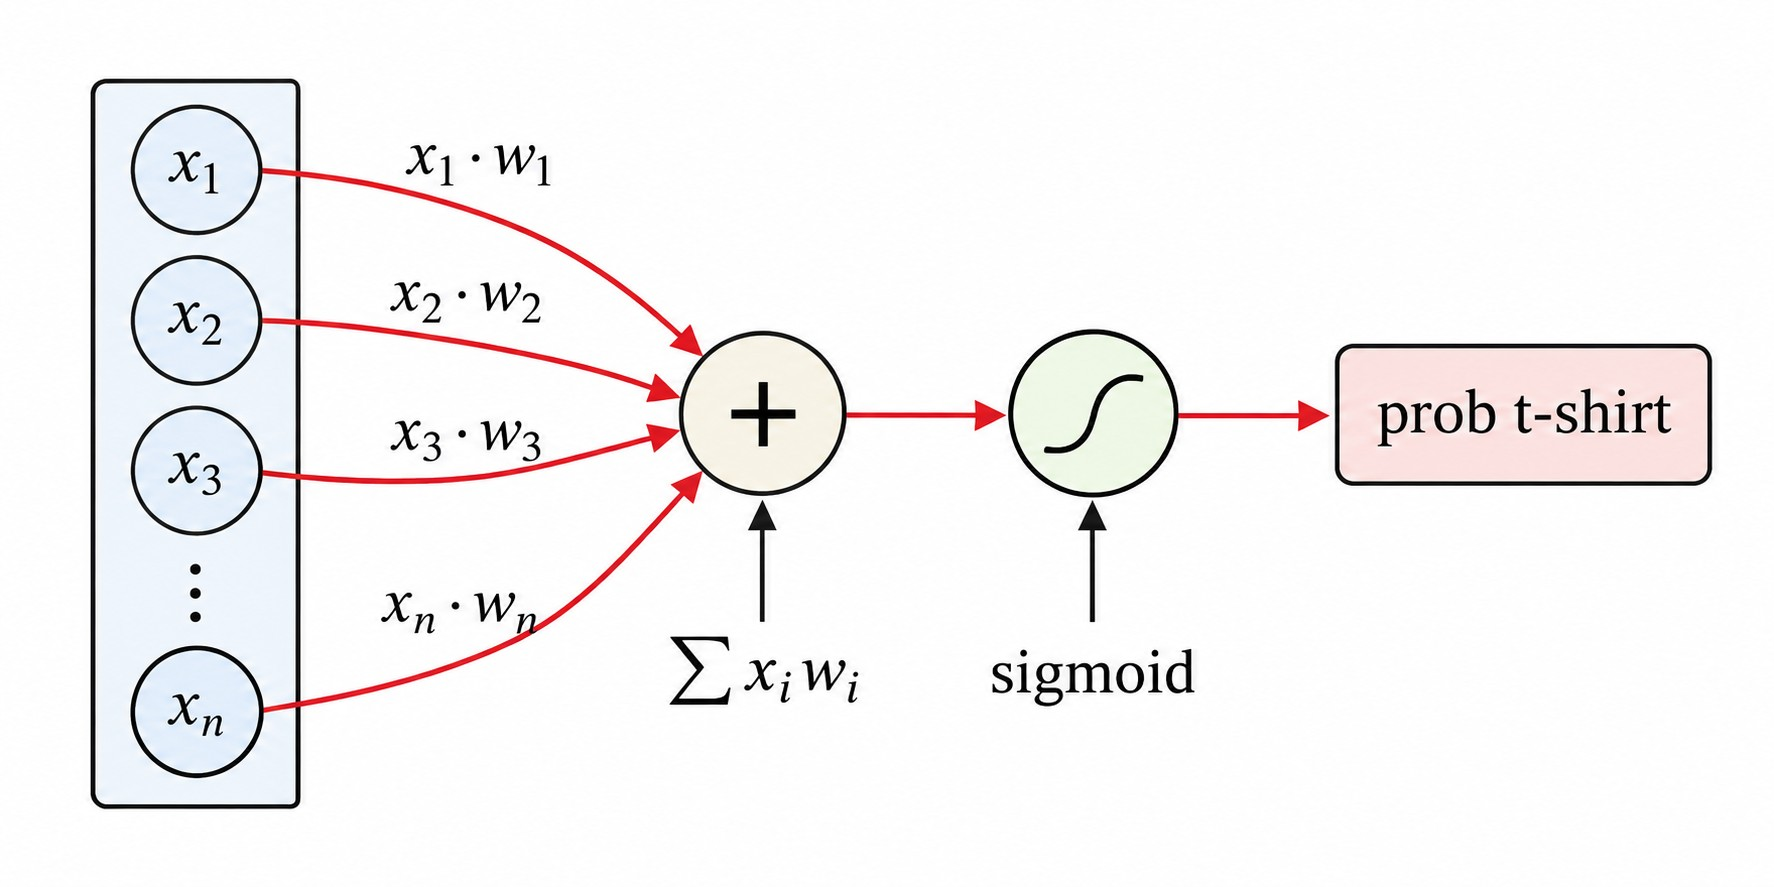

Concretely: the elements of x are x1,x2,x3, up to xn. We multiply each of them by its weight, w1,w2,w3, and so on, and sum everything together. Then we apply the sigmoid to this sum to turn it into a probability of being a t-shirt.

Let's imagine we want multiple classes: in addition to t-shirt, a shirt and a dress. WE can build three models, one per class. Each model gets the same input, the vector representation, but each has its own set of weights. Instead of sigmoid, for multiple classes we use softmax, it's a generalization of sigmoid to multiple classes. The output is a 3D vector. What we have done is put multiple logistic regressions together, and we got a NN.

This layer is called Dense, the input to the layer is the vector representation and the output is the predictions

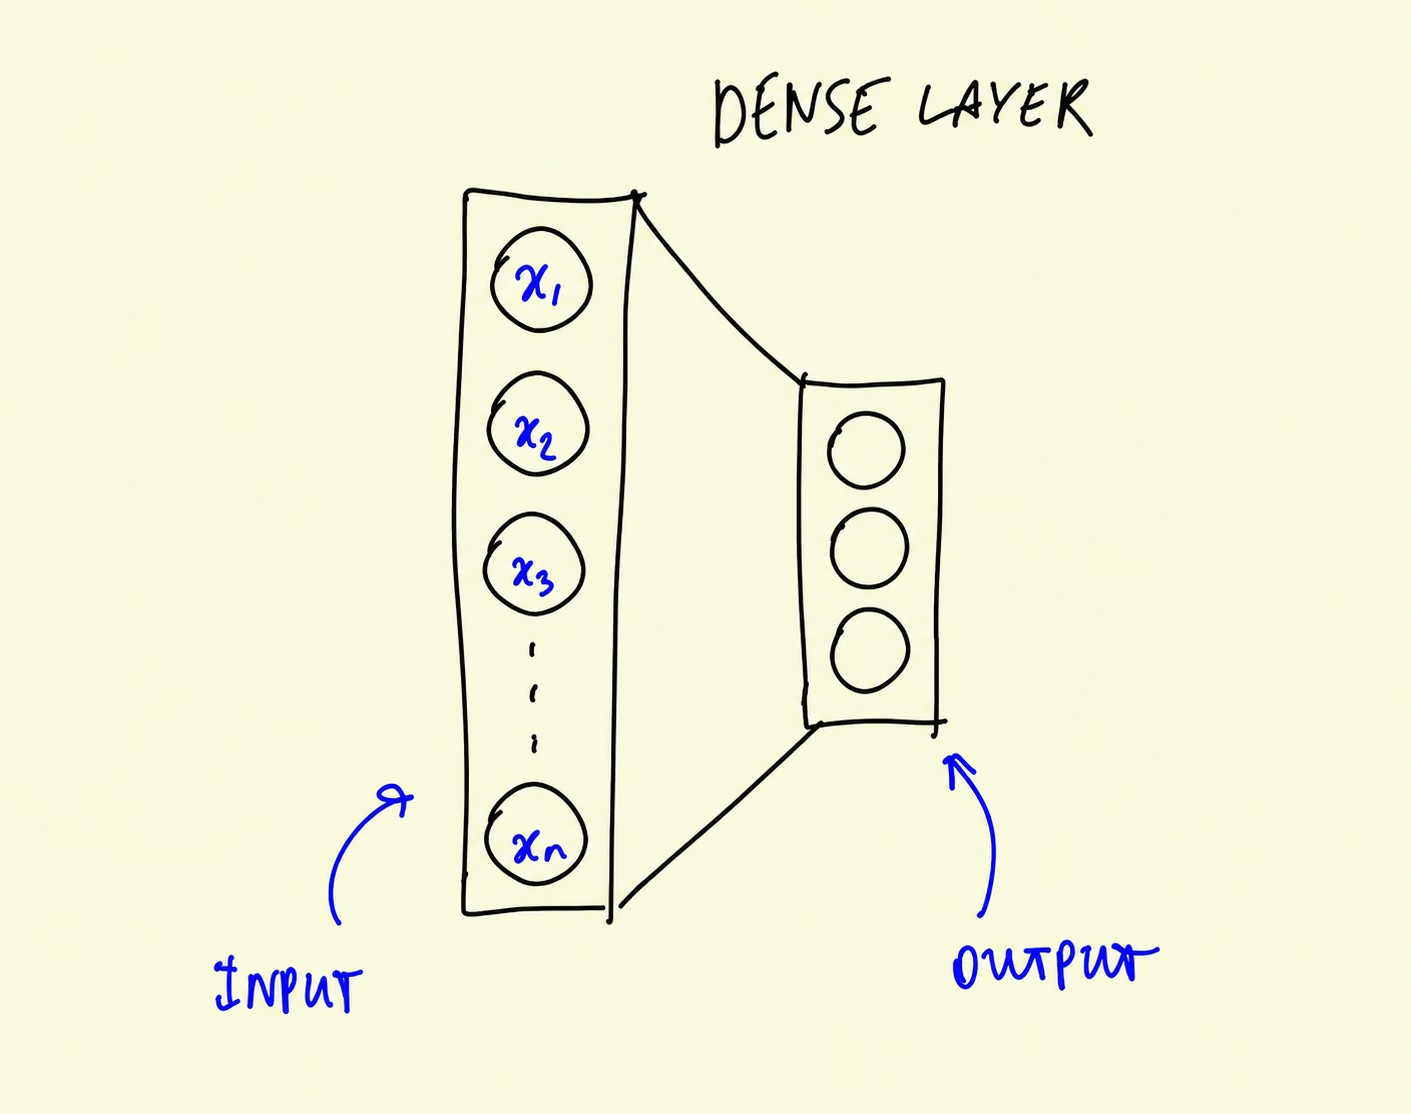

Dense because each element of the input is connected to each element of the output, for each output we have a weight:w1,w2,w3, and so on. If we put all these w's together, we get one big matrix W, where each row is the w of one output. If x is a column vector, then to transform the input to the output, all we need to do is multiply W by x. A dense layer is nothing else but matrix multiplication. We can put multiple dense layers together. The layer between the input and the final predictions is called an inner dense layer, and the last one is the final dense layer for predictions.

## Note

A convolutional NN, or CNN, is a feed-forward NN that is generally used to analyze visual images by processing data with grid-like topology. A CNN is used to detect and classify objects in an image. In CNNs, every image is represented in the form of an array of pixel values.

The convolution operation forms the basis of any CNN. In a convolution operation, the arrays are multiplied element-wise, and the dot product is summer to create a new array, which represents Wx.

A Convolution neural network has multiple hidden layers that help in extracting info from an image. The four important layers in CNN:
- Conv layer
- ReLU layer
- Pooling layer
- Fully connected layer (Dense)

### Convolution layer

First step in the process of extracting valuable features from an image. A convolution layer has several filters that perform the convolution operation. Every image is considered as a matrix of pixel values.

In [12]:
"""
nn.Conv2d(
    in_channels,
    out_channels,
    kernel_size,
    stride,
    padding,
)
"""

'\nnn.Conv2d(\n    in_channels,\n    out_channels,\n    kernel_size,\n    stride,\n    padding,\n)\n'

- in_channels: Input depth
- out_channels: Num of filters the layer will learn. Each produces one output feature map
- kernel_size: Size of convolutional filter
- stride: How many pixels the filter moves each step

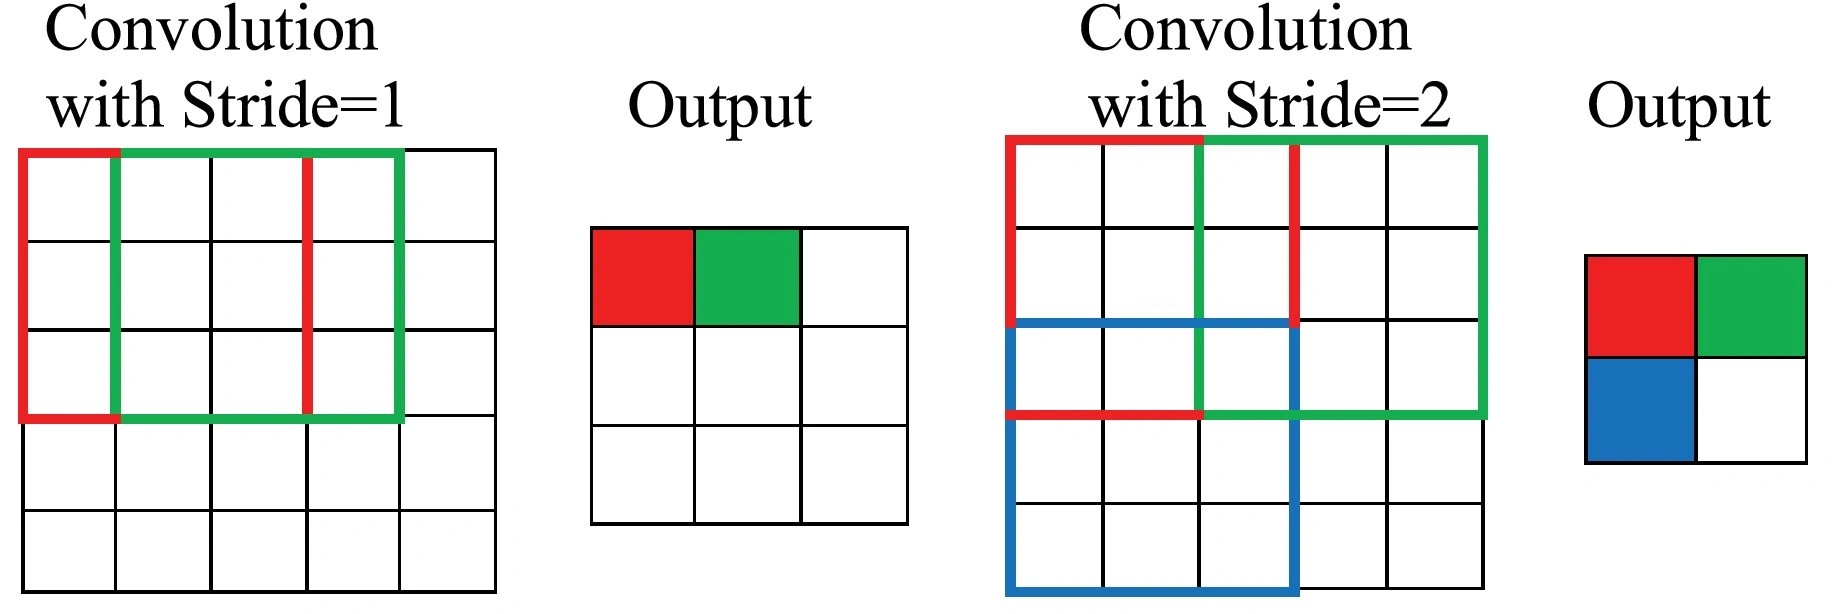

- padding: Number of pixels added around the input to control output size

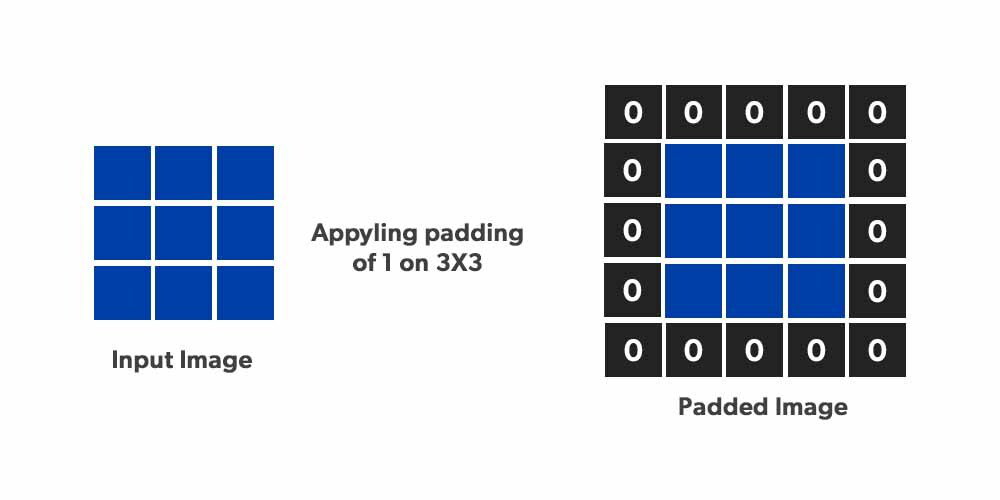

Output after Conv2d image:

$Output size = \frac{W-K+2P}{S}+1$

Where:
- W = input size (height or width)
- K = kernel size
- P = padding
- S = stride

### ReLU layer

Once the feature maps are extracted, the next step is to move them to a ReLU layer. ReLU (Rectified Linear Unit) is an activation function which performs an element-wise operation and sets all the negative pixels to 0. It introduces non-linearity to the network, and the generated output is a rectified feature map.

$f(x) = max(0,x)$

### Pooling layer

Down-sampling operation reducing the dimensionality of the feature map. The rectified map goes through a pooling layer to generate a pooled feature map. Imagine a rectified feature map of size 4x4 goes through a max pooling filter of 2x2 size with stride of 2. In this case, the resultant pooled feature map will have pooled feature map of 2x2 size where each value will represent the maximum value of each stride.

### Flatten layer

Flattening is used to convert all the 2D arrays from poled feature maps into a single linear vector. This flattened vector is then fed as input to the fully connected layer.

# Transfer Learning

Each layer of NN contains a bunch of filters, which are learnable. The model learns them during training and the filters it learns are quite generic.
Training these filters in the Convolutional layers is very difficult: the model needs to see a huge amount of images to come up with filters that make sense. But once trained, the model can take any picture and convert it into a vector representation and is quite generic.

The dense layers are different. They are specific to the dataset the model was trained on.
The plan is then:
- Keep the convolutional layers, they already know how to turn an image into a vector representation.
- Throw away the dense layers from ImageNet and train our own dense layers for our 10 classes.

In [13]:
import os
from torch.utils.data import Dataset

In [14]:
class ClothingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.image_paths=[]
        self.labels=[]
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for label_name in self.classes:
            label_dir = os.path.join(data_dir, label_name)
            for img_name in os.listdir(label_dir):
                self.image_paths.append(os.path.join(label_dir, img_name))
                self.labels.append(self.class_to_idx[label_name])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        img_path = self.image_paths[index]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)
        return image, label

## Simple Preprocessing

In [15]:
input_size = 224

# ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# Simple transforms
train_transforms = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

val_transforms = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

## Create Dataloader

In [16]:
from torch.utils.data import DataLoader

train_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/train',
    transform=train_transforms
)

val_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/validation',
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Build the model

In [17]:
import torch.nn as nn
import  torchvision.models as models

In [18]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        #Load pre-trained mobilenet
        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        #Freeze base model params
        for param in self.base_model.parameters():
            param.requires_grad = False

        #Remove original classifier
        self.base_model.classifier = nn.Identity()

        #Add custom layers
        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.output_layer = nn.Linear(1280, num_classes)

    def forward(self,x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x,1)
        x = self.output_layer(x)
        return x

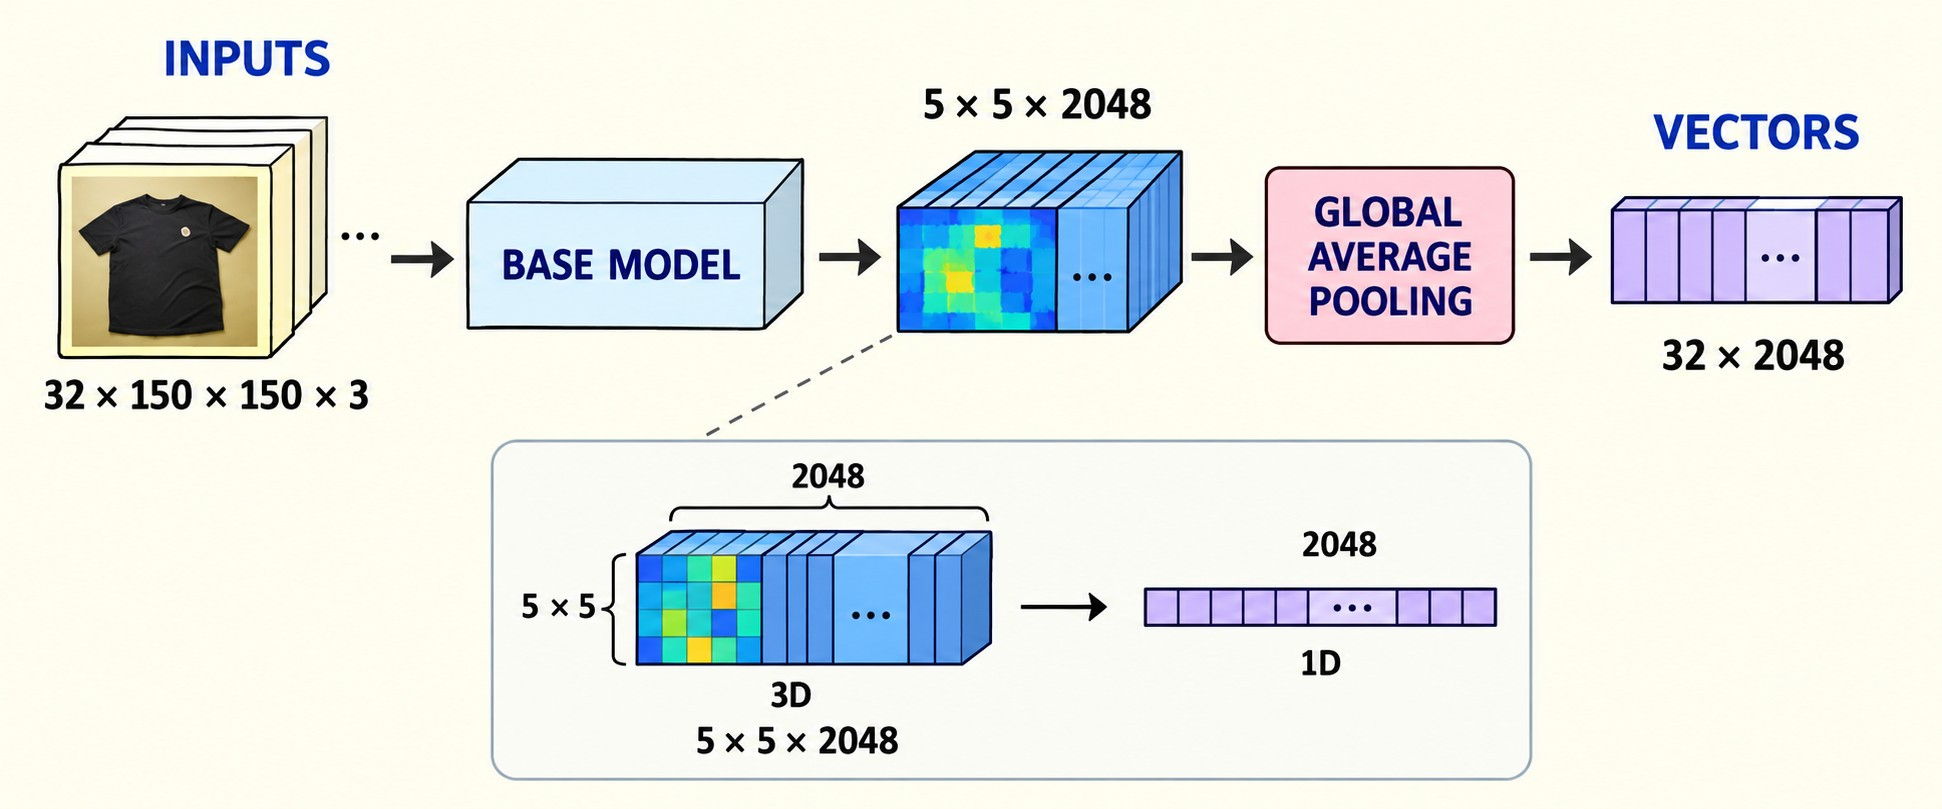

## Train model

In [19]:
import torch.optim as optim

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = ClothingClassifierMobileNet(num_classes=10).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

cuda


To train the model we need two things: an optimizer and a loss.

The optimizer is the thing that finds the best weights for the model. Remember the dense layer is a matrix W, training means changing each element of this matrix and checking whether the solution gets better, many times. The optimizer does that. It does not change the weights randomly, it tries to change them in such a way that the model actually learns something.

There are quite a few optimizer, we use Adam. The optimizer needs to know how to check whether changing the weights made things better or worse. For that there is the concept of loss: the loss tells us how good the model is. Since this is a multi-class classification problem, we use categorical cross-entropy. For binary classification we use binary cross-entropy, and for regression, mean squared error.

In [21]:
num_epoch = 10

for epoch in range(num_epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data,1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{num_epoch}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/10
Train Loss: 1.2885, Train Acc: 0.5945
Val loss: 0.9284, Val Acc: 0.6862
Epoch 2/10
Train Loss: 0.7196, Train Acc: 0.7862
Val loss: 0.7116, Val Acc: 0.7742
Epoch 3/10
Train Loss: 0.5870, Train Acc: 0.8175
Val loss: 0.6447, Val Acc: 0.8006
Epoch 4/10
Train Loss: 0.5248, Train Acc: 0.8292
Val loss: 0.6033, Val Acc: 0.8006
Epoch 5/10
Train Loss: 0.4797, Train Acc: 0.8478
Val loss: 0.6098, Val Acc: 0.8006
Epoch 6/10
Train Loss: 0.4290, Train Acc: 0.8651
Val loss: 0.5965, Val Acc: 0.7859
Epoch 7/10
Train Loss: 0.4224, Train Acc: 0.8611
Val loss: 0.5882, Val Acc: 0.7977
Epoch 8/10
Train Loss: 0.3975, Train Acc: 0.8722
Val loss: 0.6165, Val Acc: 0.7889
Epoch 9/10
Train Loss: 0.3787, Train Acc: 0.8797
Val loss: 0.5965, Val Acc: 0.7889
Epoch 10/10
Train Loss: 0.3654, Train Acc: 0.8833
Val loss: 0.6146, Val Acc: 0.7830


In [22]:
def train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

## Tuning the learning rate

In [23]:
def make_model(learning_rate=0.01):
    model = ClothingClassifierMobileNet(num_classes=10)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [24]:
learning_rate = [0.0001,0.001,0.01,0.1]

for lr in learning_rate:
    print(f"\n Learning Rate: {lr}")
    model, optimizer = make_model(lr)
    train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epoch, device)


 Learning Rate: 0.0001
Epoch 1/10
  Train Loss: 1.9853, Train Acc: 0.2920
  Val Loss: 1.7640, Val Acc: 0.4311
Epoch 2/10
  Train Loss: 1.6163, Train Acc: 0.4879
  Val Loss: 1.4695, Val Acc: 0.5484
Epoch 3/10
  Train Loss: 1.3683, Train Acc: 0.5896
  Val Loss: 1.2846, Val Acc: 0.6393
Epoch 4/10
  Train Loss: 1.2141, Train Acc: 0.6503
  Val Loss: 1.1522, Val Acc: 0.6891
Epoch 5/10
  Train Loss: 1.0952, Train Acc: 0.7011
  Val Loss: 1.0570, Val Acc: 0.7126
Epoch 6/10
  Train Loss: 1.0000, Train Acc: 0.7376
  Val Loss: 0.9807, Val Acc: 0.7214
Epoch 7/10
  Train Loss: 0.9326, Train Acc: 0.7461
  Val Loss: 0.9282, Val Acc: 0.7273
Epoch 8/10
  Train Loss: 0.8751, Train Acc: 0.7715
  Val Loss: 0.8831, Val Acc: 0.7419
Epoch 9/10
  Train Loss: 0.8230, Train Acc: 0.7832
  Val Loss: 0.8430, Val Acc: 0.7625
Epoch 10/10
  Train Loss: 0.7894, Train Acc: 0.7823
  Val Loss: 0.8162, Val Acc: 0.7771

 Learning Rate: 0.001
Epoch 1/10
  Train Loss: 1.2874, Train Acc: 0.6030
  Val Loss: 0.9196, Val Acc: 0.

## Model checkpointing

In [25]:
def train_and_evaluate_with_checkpointing(model, optimizer, train_loader, val_loader, criterion, num_epochs, device):
    best_val_accuracy=0.0

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        checkpoint_path = f'mobilenet_v2_{epoch+1:02d}_{val_acc:.4f}.pth'
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")

## Adding Inner Layers

We can add more layers between the vector representation and the output layer. These are the same dense layers as the output layer, the difference is that intermediate layers use an activation function for non-linearity. Without it, stacking dense layers would not help.
Each activation takes the raw scores coming out of a dense layer and transforms them. Softmax turns raw scores into probabilities, that's what we use for the output layer. For intermediate layers the usual choice is ReLU: negative input becomes zero, positive goes through.

In [26]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)  # New inner layer
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

In [27]:
def make_model(learning_rate=0.01, size_inner=100):
    model = ClothingClassifierMobileNet(num_classes=10, size_inner=size_inner)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [ ]:
learning_rate = 0.001

scores = {}

for size in [10, 100, 1000]:
    print(size)

    model, optimizer = make_model(learning_rate=learning_rate, size_inner=size)
    history = train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, num_epoch, device)

10


# Dropout

Instead of shrinking it back, we'll try to regularize it. Regularization is a way to keep a model from overfitting, and the technique we use is dropout.

When we train for 10 epochs, th emodel sees every image 10 times. It may start to latch onto details instead of learning general features. What we want instead is for the model to focus on the bigger picture.

Dropout addresses this by hiding part of the network at each iteration, not the image itself, but the input to the inner dense layer. The intuition: it's as if we hid random parts of the image with a black patch at each step, so the model never sees the same image twice.

Take a dense layer with 4 inputs and 3 outputs. With dropout, each training step freezes part of this layer: some inputs are set to zero and do not participate in that step. The next step freezes a different part. The output layer sees all the parts including frozen ones. Drop_rate param controls how much is hidden, with 0.5, each iteration freezes 50% of the layer. Dropout does not change the dimensionality of the layer, it only temporarily zeros out parts of it while training.

Dropout randomly drops neurons during training to prevent overfitting.

How it works:

Training: randomly set fraction of activations to 0
Inference: use all neurons (dropout disabled automatically)
Creates ensemble effect
Benefits:

Prevents relying on specific features
Forces learning robust patterns
Reduces overfitting

In [34]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x

In [35]:
def make_model(
        learning_rate=0.001,
        size_inner=100,
        droprate=0.2
):
    model = ClothingClassifierMobileNet(
        num_classes=10,
        size_inner=size_inner,
        droprate=droprate
    )
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [31]:
for droprate in [0.0,0.2,0.8]:
    print(droprate)

    model, optimizer = make_model(droprate=droprate)
    history = train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, 30, device)

0.0
Epoch 1/30
  Train Loss: 1.2239, Train Acc: 0.6170
  Val Loss: 0.7727, Val Acc: 0.7625
Epoch 2/30
  Train Loss: 0.6765, Train Acc: 0.7855
  Val Loss: 0.6492, Val Acc: 0.7771
Epoch 3/30
  Train Loss: 0.5536, Train Acc: 0.8198
  Val Loss: 0.5949, Val Acc: 0.8240
Epoch 4/30
  Train Loss: 0.4716, Train Acc: 0.8452
  Val Loss: 0.5757, Val Acc: 0.8035
Epoch 5/30
  Train Loss: 0.4395, Train Acc: 0.8491
  Val Loss: 0.6469, Val Acc: 0.7742
Epoch 6/30
  Train Loss: 0.4120, Train Acc: 0.8523
  Val Loss: 0.5883, Val Acc: 0.8123
Epoch 7/30
  Train Loss: 0.3985, Train Acc: 0.8618
  Val Loss: 0.6286, Val Acc: 0.8094
Epoch 8/30
  Train Loss: 0.3475, Train Acc: 0.8801
  Val Loss: 0.6356, Val Acc: 0.7830
Epoch 9/30
  Train Loss: 0.3393, Train Acc: 0.8810
  Val Loss: 0.6973, Val Acc: 0.7771
Epoch 10/30
  Train Loss: 0.3306, Train Acc: 0.8843
  Val Loss: 0.7023, Val Acc: 0.7742
Epoch 11/30
  Train Loss: 0.2876, Train Acc: 0.9016
  Val Loss: 0.6548, Val Acc: 0.7977
Epoch 12/30
  Train Loss: 0.2595, Tra

Downside of dropout is that the model needs more iterations to learn, at each step it can't use the whole network, so learning is slower.

# Data Augmentation

Dropout regularize the network, data augmentation is another way to fight overfitting, this time on the side of the data. We generate more training images from the existing ones by applying random transformations, so the network never sees the same image twice in the same form.

## What it looks like

There are many transformations we can apply, and we can combine them:
- flipping the image horizontally or vertically
- rotating it or shifting it left/right and up/down
- shearing: moving one of the corners so the image gets skewed
- zooming in or out
- changing brightness and contrast

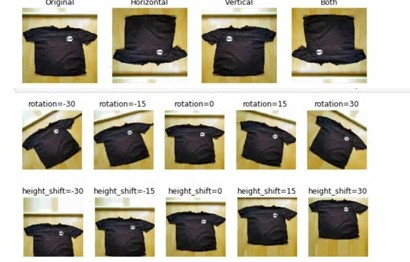
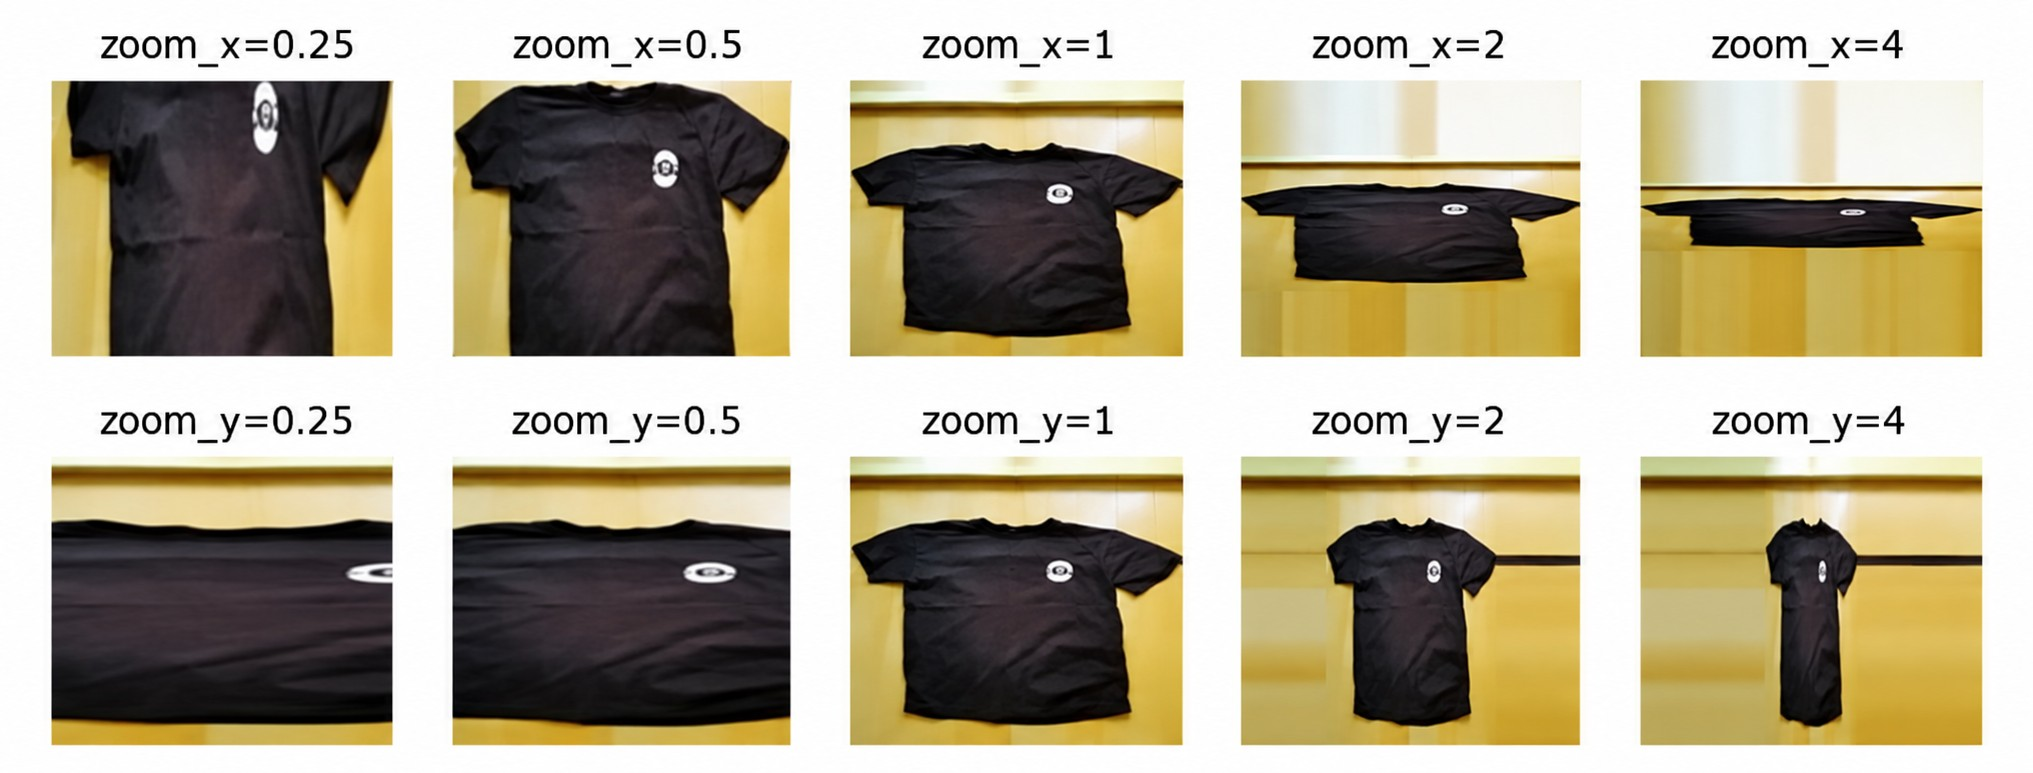

Idea is similary to dropout, augmentation can randomly hide parts of the image, and it changes details, forcing the model to learn the shape rather than the details.

An important detail: Augmentation should be applied only to the training data, never the validation. We leave the validation dataset unchanged, because we want consistent results: the validation images must always be the same, otherwise the scores are not comparable.

In [36]:
training_transforms = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.9,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [37]:
model, optimizer = make_model()
train_and_evaluate(model, optimizer, train_loader, val_loader, criterion, 30, device)

Epoch 1/30
  Train Loss: 1.3084, Train Acc: 0.5684
  Val Loss: 0.8083, Val Acc: 0.7537
Epoch 2/30
  Train Loss: 0.7677, Train Acc: 0.7366
  Val Loss: 0.6920, Val Acc: 0.7771
Epoch 3/30
  Train Loss: 0.6325, Train Acc: 0.7976
  Val Loss: 0.6521, Val Acc: 0.7625
Epoch 4/30
  Train Loss: 0.5513, Train Acc: 0.8136
  Val Loss: 0.5983, Val Acc: 0.7977
Epoch 5/30
  Train Loss: 0.5024, Train Acc: 0.8272
  Val Loss: 0.5761, Val Acc: 0.7977
Epoch 6/30
  Train Loss: 0.4705, Train Acc: 0.8383
  Val Loss: 0.5758, Val Acc: 0.8094
Epoch 7/30
  Train Loss: 0.4515, Train Acc: 0.8419
  Val Loss: 0.5896, Val Acc: 0.7889
Epoch 8/30
  Train Loss: 0.4220, Train Acc: 0.8592
  Val Loss: 0.5485, Val Acc: 0.8123
Epoch 9/30
  Train Loss: 0.3669, Train Acc: 0.8771
  Val Loss: 0.5732, Val Acc: 0.8094
Epoch 10/30
  Train Loss: 0.3811, Train Acc: 0.8690
  Val Loss: 0.5875, Val Acc: 0.7977
Epoch 11/30
  Train Loss: 0.3445, Train Acc: 0.8817
  Val Loss: 0.6416, Val Acc: 0.7771
Epoch 12/30
  Train Loss: 0.3325, Train A

# Large model

Now that parameters are chosen, it's time to train the final, larger model on images of the original size, using everything we have learned.

In [38]:
class ClothingClassifierMobileNet(nn.Module):
    def __init__(self, size_inner=100, droprate=0.2, num_classes=10):
        super(ClothingClassifierMobileNet, self).__init__()

        self.base_model = models.mobilenet_v2(weights='IMAGENET1K_V1')

        for param in self.base_model.parameters():
            param.requires_grad = False

        self.base_model.classifier = nn.Identity()

        self.global_avg_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.inner = nn.Linear(1280, size_inner)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(droprate)  # Add dropout
        self.output_layer = nn.Linear(size_inner, num_classes)

    def forward(self, x):
        x = self.base_model.features(x)
        x = self.global_avg_pooling(x)
        x = torch.flatten(x, 1)
        x = self.inner(x)
        x = self.relu(x)
        x = self.dropout(x)  # Apply dropout
        x = self.output_layer(x)
        return x

In [39]:
def make_model(learning_rate=0.001, size_inner=100, droprate=0.2):
    model = ClothingClassifierMobileNet(size_inner=size_inner, droprate=droprate)
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    return model, optimizer

In [40]:
input_size = 290

train_transforms = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(input_size, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/train',
    transform=train_transforms
)

val_dataset = ClothingDataset(
    data_dir='./clothing-dataset-small/validation',
    transform=val_transforms
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## Training the final model

We train the final model with the best hyperparameters found earlier (`size_inner=100`, `droprate=0.2`, `learning_rate=0.001`), on the larger `290x290` images, with data augmentation on the training set. The training loop records the loss and accuracy for every epoch so we can inspect the training history afterwards, and checkpoints the model whenever validation accuracy improves.

In [41]:
def train_final_model(model, optimizer, train_loader, val_loader, criterion, num_epochs, device, checkpoint_dir='.'):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}')
        print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
        print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            checkpoint_path = f'{checkpoint_dir}/mobilenet_v2_final_{epoch+1:02d}_{val_acc:.4f}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'  Checkpoint saved: {checkpoint_path}')

    return history

In [42]:
model, optimizer = make_model(learning_rate=0.001, size_inner=100, droprate=0.2)

history = train_final_model(
    model, optimizer, train_loader, val_loader, criterion,
    num_epochs=30, device=device
)

Epoch 1/30
  Train Loss: 1.6546, Train Acc: 0.4498
  Val Loss: 1.2100, Val Acc: 0.5982
  Checkpoint saved: ./mobilenet_v2_final_01_0.5982.pth
Epoch 2/30
  Train Loss: 1.1376, Train Acc: 0.6203
  Val Loss: 0.9535, Val Acc: 0.6540
  Checkpoint saved: ./mobilenet_v2_final_02_0.6540.pth
Epoch 3/30
  Train Loss: 0.9268, Train Acc: 0.6930
  Val Loss: 0.7797, Val Acc: 0.7742
  Checkpoint saved: ./mobilenet_v2_final_03_0.7742.pth
Epoch 4/30
  Train Loss: 0.8425, Train Acc: 0.7164
  Val Loss: 0.6966, Val Acc: 0.7742
Epoch 5/30
  Train Loss: 0.8001, Train Acc: 0.7298
  Val Loss: 0.6793, Val Acc: 0.7859
  Checkpoint saved: ./mobilenet_v2_final_05_0.7859.pth
Epoch 6/30
  Train Loss: 0.7139, Train Acc: 0.7608
  Val Loss: 0.6773, Val Acc: 0.7830
Epoch 7/30
  Train Loss: 0.6849, Train Acc: 0.7696
  Val Loss: 0.6389, Val Acc: 0.7977
  Checkpoint saved: ./mobilenet_v2_final_07_0.7977.pth
Epoch 8/30
  Train Loss: 0.6540, Train Acc: 0.7836
  Val Loss: 0.6469, Val Acc: 0.7771
Epoch 9/30
  Train Loss: 0.61

## Plotting the training history

A small helper to visualize how loss and accuracy evolved on the train and validation sets across epochs.

In [43]:
import matplotlib.pyplot as plt


def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 5))

    ax_loss.plot(epochs, history['train_loss'], label='Train')
    ax_loss.plot(epochs, history['val_loss'], label='Validation')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title('Loss per epoch')
    ax_loss.legend()

    ax_acc.plot(epochs, history['train_acc'], label='Train')
    ax_acc.plot(epochs, history['val_acc'], label='Validation')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_title('Accuracy per epoch')
    ax_acc.legend()

    plt.tight_layout()
    plt.show()

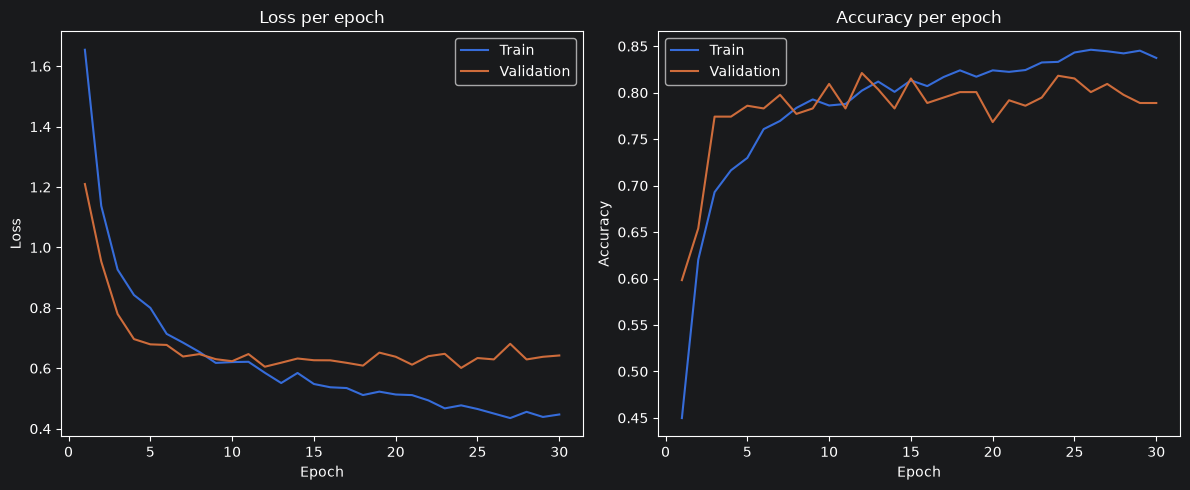

In [44]:
plot_training_history(history)

In [45]:
import glob

# find best checkpoint
list_of_files = glob.glob('mobilenet_v2_final_*.pth')
latest_file = max(list_of_files, key=os.path.getctime)
print(f"Latest model from: {latest_file}")

model = ClothingClassifierMobileNet(size_inner=100, droprate=0.2, num_classes=10)
model.load_state_dict(torch.load(latest_file, map_location=device))
model.to(device)
model.eval()

Latest model from: mobilenet_v2_final_12_0.8211.pth


ClothingClassifierMobileNet(
  (base_model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActiva

# Making Predictions

In [46]:
import requests
from io import BytesIO

In [47]:
def load_image_from_url(url):
    response = requests.get(url)
    return Image.open(BytesIO(response.content)).convert('RGB')

predict_transforms = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

url = 'https://bit.ly/mlbookcamp-pants'
img = load_image_from_url(url)
x = predict_transforms(img).unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(x).cpu().numpy()[0]

classes = [
    "dress", "hat", "longsleeve", "outwear", "pants",
    "shirt", "shoes", "shorts", "skirt", "t-shirt"
]

result = dict(zip(classes, pred.tolist()))
print(result)

{'dress': 0.13060425221920013, 'hat': -5.619821071624756, 'longsleeve': 0.1277768611907959, 'outwear': 0.2812536656856537, 'pants': 4.072885990142822, 'shirt': -1.0361237525939941, 'shoes': -6.652021408081055, 'shorts': -2.057800531387329, 'skirt': -3.852053642272949, 't-shirt': -2.3381481170654297}


# Export to ONNX

Open Neural Network Exchange is a format for model interoperability

Benefits:
- Deploy on diff platforms
- Use optimized runtimes
- Better inference performance
- Language-agnostic deployment

In [48]:
dummy_input = torch.randn(1, 3, input_size, input_size).to(device)
onnx_path = "clothing_classifier_mobilenet_v2.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    verbose=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'},
    }
)

print(f"Model exported to: {onnx_path}")

/tmp/ipykernel_18651/1234094621.py:4: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `ClothingClassifierMobileNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ClothingClassifierMobileNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to: clothing_classifier_mobilenet_v2.onnx
